# Predição de Doença Cardíaca com Machine Learning
### 📌 Estrutura
1. Carregamento e limpeza dos dados
2. Análise exploratória (EDA)
3. Pré-processamento
4. Modelagem — Regressão Logística, Árvore de Decisão, Random Forest, XGBoost
5. Avaliação do modelo final
6. Interpretabilidade — coeficientes e SHAP
7. Conclusões clínicas

---

### ⚕️ Sobre o dataset
O Cleveland Heart Disease Dataset foi escolhido por ser o benchmark mais
utilizado na literatura de ML aplicado à cardiologia — com décadas de
estudos publicados usando esses dados. apesar das limitações conhecidas
(303 pacientes, dados de 1988), é o dataset ideal para demonstrar técnicas
de ML em contexto clínico porque suas variáveis têm significado clínico
bem documentado e os resultados são comparáveis com a literatura existente.
o objetivo não é construir um modelo pronto para produção, mas demonstrar
o raciocínio analítico completo, da EDA à interpretabilidade, num domínio
de alto impacto.

## 1. Carregamento e Limpeza dos Dados

In [1]:
!pip install ucimlrepo -q
!pip install xgboost -q

In [2]:
# versões utilizadas neste notebook
# pra reproduzir o ambiente, descomente e execute:

# !pip install pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 \
#   xgboost==3.2.0 shap==0.51.0 ucimlrepo==0.0.7 \
#   matplotlib==3.10.0 seaborn==0.13.2 scipy==1.16.3

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)

In [4]:
from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)
df = pd.concat([heart_disease.data.features, heart_disease.data.targets], axis=1)
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


In [5]:
# pra visualização da tabela ficar melhor, vamo renomear os nomes das colunas

df.rename(columns={'age':'idade',
                   'sex' : 'sexo',
                   'cp' : 'tipo_dor_peito',
                   'trestbps' : 'pressao_arterial_repouso',
                   'chol' : 'colesterol',
                   'fbs' : 'glicemia_jejum_alta',
                   'restecg' : 'ecg_repouso',
                   'thalach' : 'frequencia_cardiaca_maxima',
                   'exang' : 'angina_por_exercicio',
                   'oldpeak' : 'depressao_segmento_st',
                   'slope' : 'inclinacao_st',
                   'ca' : 'numero_vasos_coloridos',
                   'thal' : 'resultado_talio',
                   'num' : 'doenca_cardiaca'}, inplace=True)
df.head(10)

,idade,sexo,tipo_dor_peito,pressao_arterial_repouso,colesterol,glicemia_jejum_alta,ecg_repouso,frequencia_cardiaca_maxima,angina_por_exercicio,depressao_segmento_st,inclinacao_st,numero_vasos_coloridos,resultado_talio,doenca_cardiaca
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


In [6]:
# vamo ver se tem algum dado faltando
df.isnull().sum()

# numero_vasos_coloridos tem 4 faltantes e resultado_talio tem 2
# ambas são variáveis categóricas, então o ideal aqui é usar a moda pra preencher os NaN com os valores mais frequentes na população do dataset pra cada um deles
df['numero_vasos_coloridos'] = df['numero_vasos_coloridos'].fillna(df['numero_vasos_coloridos'].mode()[0])
df['resultado_talio'] = df['resultado_talio'].fillna(df['resultado_talio'].mode()[0]) #-> vamo incluir o [0] pra retornar o valor mais frequente

# pra confirmar se todos foram tratados
df.isnull().sum() #-> OK!

,0
idade,0
sexo,0
tipo_dor_peito,0
pressao_arterial_repouso,0
colesterol,0
glicemia_jejum_alta,0
ecg_repouso,0
frequencia_cardiaca_maxima,0
angina_por_exercicio,0
depressao_segmento_st,0


a coluna "doenca_cardiaca" é o target e representa o grau de comprometimento das artérias coronárias, variando de 0 a 4:
- 0 indica ausência de doença (com estreitamento menor que 50% em qualquer vaso principal);
- 1 a 4 representam graus crescentes de comprometimento.

como o objetivo do modelo é identificar a presença da doença, e não classificar sua gravidade, vamo binarizar o target em 0 (sem doença) e 1 (com doença, independente do grau).

In [7]:
# vamo binarizar o target -> 0 = sem doença; 1 = com doença

df['doenca_cardiaca'] = (df['doenca_cardiaca'] > 0).astype(int)

## 2. Análise Exploratória (EDA)

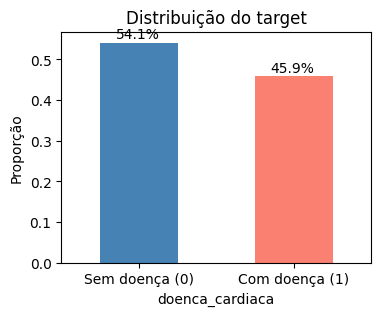

In [8]:
# vamo visualizar a distribuição do target pra saber quantos % têm doença

ax = df['doenca_cardiaca'].value_counts(normalize=True).plot(
    kind='bar', color=['steelblue', 'salmon'], figsize=(4, 3)
)
ax.set_xticklabels(['Sem doença (0)', 'Com doença (1)'], rotation=0)
ax.set_ylabel('Proporção')
ax.set_title('Distribuição do target')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + 0.1, p.get_height() + 0.01))
plt.show()

o dataset apresenta uma distribuição relativamente equilibrada entre as classes (54%/46%). de qqr forma, vamo monitorar o desempenho por classe nas métricas e avaliar a necessidade de alguma estratégia de balanceamento durante a modelagem.

In [9]:
# vamo avaliar as estatísticas descritivas por classe pra comparar os grupos

df.groupby('doenca_cardiaca').describe().T #-> vamo usar o .T pra transpor a tabela e ficar mais fácil de comparar

doenca_cardiaca                 0           1
idade           count  164.000000  139.000000
                mean    52.585366   56.625899
                std      9.511957    7.938416
                min     29.000000   35.000000
                25%     44.750000   52.000000
...                           ...         ...
resultado_talio min      3.000000    3.000000
                25%      3.000000    3.000000
                50%      3.000000    7.000000
                75%      3.000000    7.000000
                max      7.000000    7.000000

[104 rows x 2 columns]

com o .describe() dá pra gente perceber algumas coisas:
- a média da pressao_arterial_repouso, colesterol e depressao_segmento_st na classe "com doença" é levemente maior. Isso faz total sentido clinicamente já que pressão arterial elevada indica hipertensão (que é um dos principais fatores de risco cardíaco), colesterol alto está diretamente associado ao acúmulo de placas nas artérias, e valores maiores de depressão do segmento ST indicam maior comprometimento do músculo cardíaco;
- já a média da frequencia_cardiaca_maxima na classe "com doença" é levemente menor, o que tbm é o esperado, ja que corações comprometidos respondem com menor eficiência ao esforço físico.

aqi a gente consegue avaliar as variáveis numéricas. as categóricas ainda vão ser analisadas separadamente em outro momento.

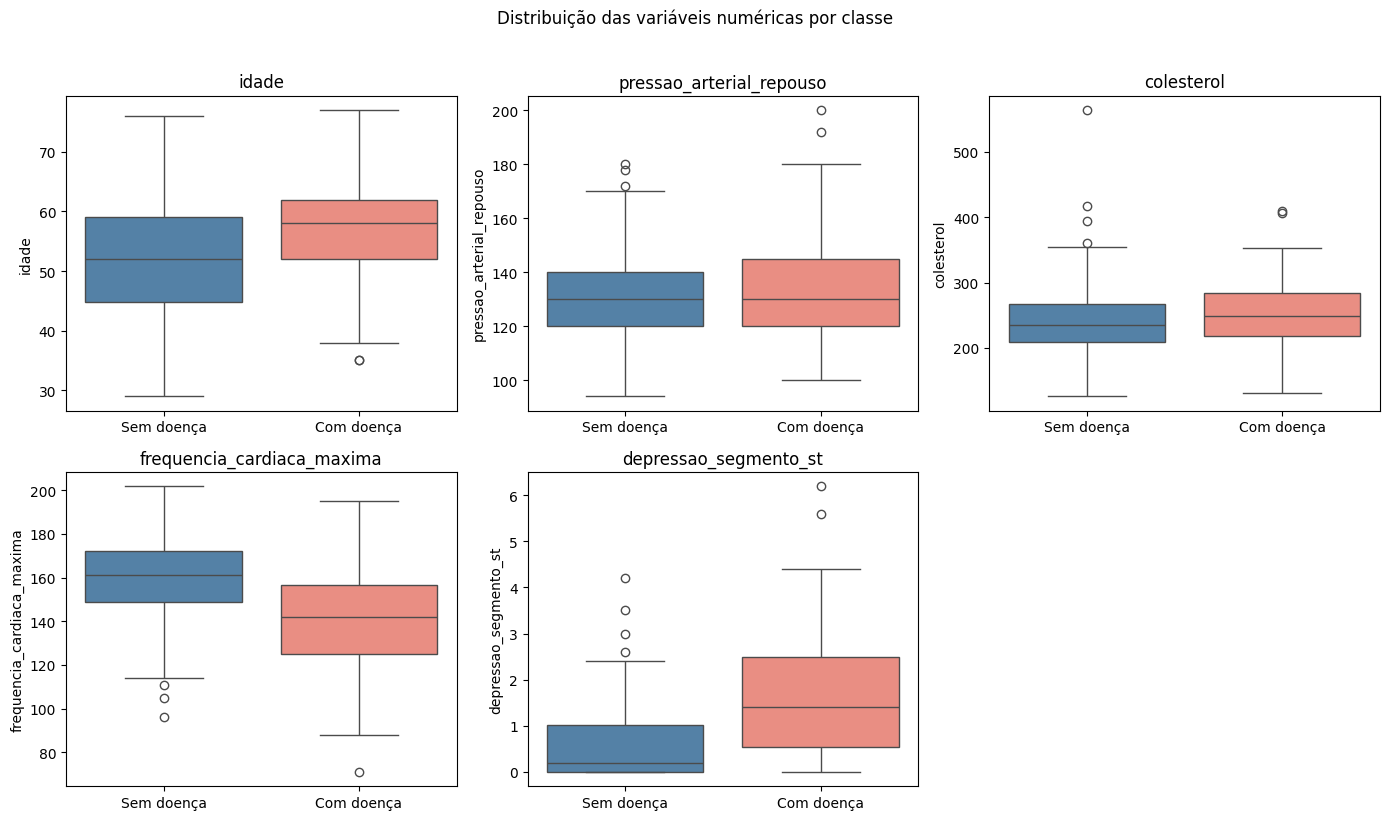

In [10]:
# vamo gerar boxplots pra visualizar a distribuição das variáveis numéricas por classes

variaveis_numericas = ['idade', 'pressao_arterial_repouso', 'colesterol',
                        'frequencia_cardiaca_maxima', 'depressao_segmento_st']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(variaveis_numericas):
    sns.boxplot(x='doenca_cardiaca', y=var, data=df, hue='doenca_cardiaca', palette=['steelblue', 'salmon'], legend=False, ax=axes[i])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Sem doença', 'Com doença'])
    axes[i].set_title(var)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)  #-> pra esconder o último subplot vazio
plt.suptitle('Distribuição das variáveis numéricas por classe', y=1.02)
plt.tight_layout()
plt.show()

os boxplots mostram alguns outliers, mas nenhum deles se mostram como valores impossíveis clinicamente, mesmo que extremos. eles podem representar pacientes reais com perfis fisiológicos atípicos, e remover esses valores seria perder um perfil de risco real que podem carregar informações diagnósticas importantes.

como não temos nenhuma evidência clara de erro de medição, vamo manter todos os valores aí.

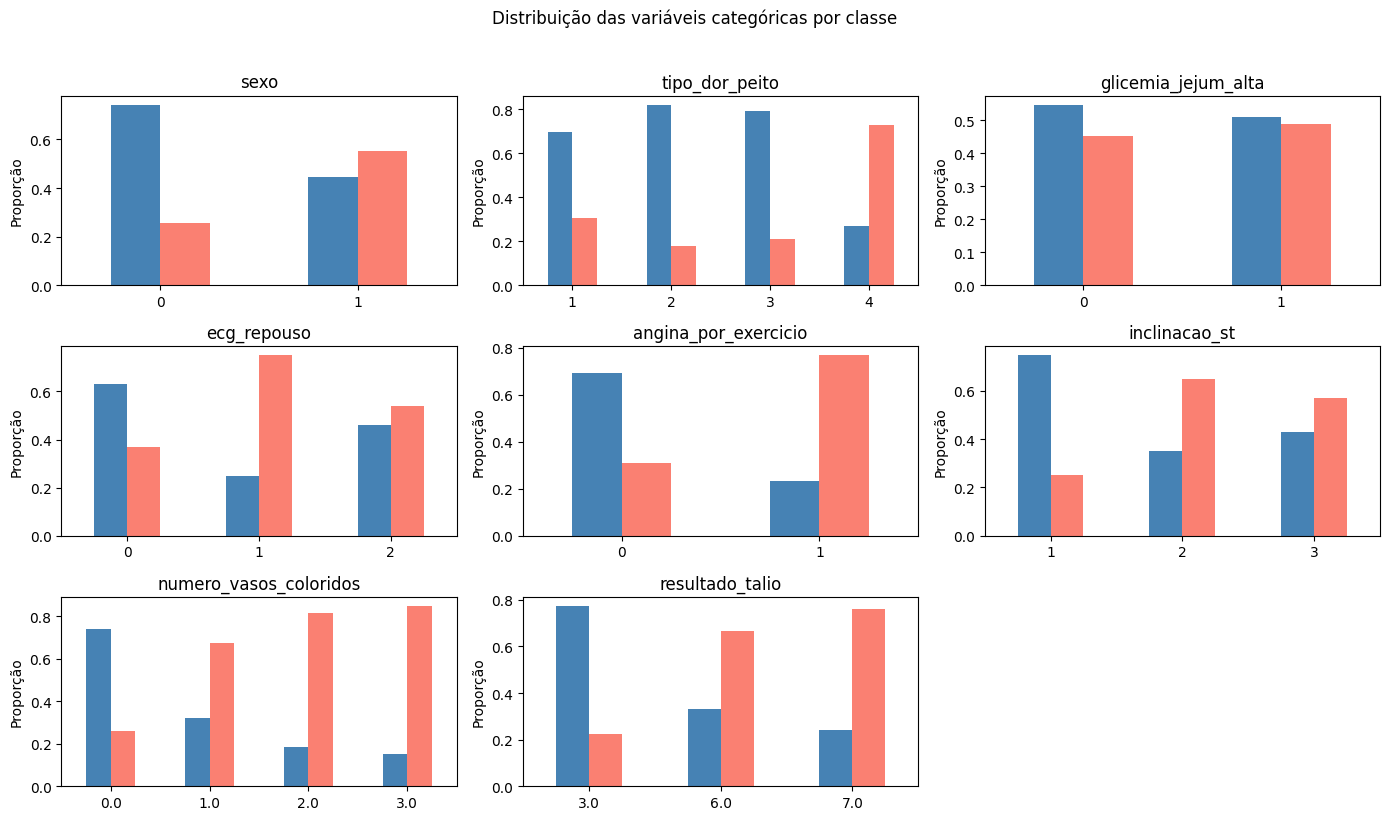

In [11]:
# agora vamo gerar barplots pra visualizar a distribuição das variáveis categóricas tbm

variaveis_categoricas = ['sexo', 'tipo_dor_peito', 'glicemia_jejum_alta',
                          'ecg_repouso', 'angina_por_exercicio',
                          'inclinacao_st', 'numero_vasos_coloridos', 'resultado_talio']

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(variaveis_categoricas):
    proporcao = df.groupby([var, 'doenca_cardiaca']).size().unstack(fill_value=0) #-> pra organizar os dados por categoria e classe
    proporcao = proporcao.div(proporcao.sum(axis=1), axis=0)  #-> pra converter as contagens brutas em proporções
    proporcao.plot(kind='bar', ax=axes[i], color=['steelblue', 'salmon'], legend=False, rot=0)
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proporção')

axes[-1].set_visible(False)
plt.suptitle('Distribuição das variáveis categóricas por classe', y=1.02)
plt.tight_layout()
plt.show()
# azul (0) = sem doença | salmão (1) = com doença

cada barra nos barplots mostra a proporção dentro daquela categoria específica. algumas variáveis mostram separação clara entre as classes:
- a categoria 4 de tipo_dor_peito significa assintomático, ou seja: o paciente não sente dor no peito. Mesmo assim, essa categoria concentra mais casos de doença cardíaca confirmada. isso parece contraditório, mas apenas significa que a doença pode existir mesmo sem sintomas perceptíveis (não tem nada a ver com a ausência de dor causar doença). clinicamente isso é documentado como isquemia silenciosa, que significa que a doença pode ir evoluindo sem dor perceptível, sendo descoberta apenas em exames preventivos;
- glicemia_jejum_alta tem uma distribuição relativamente equilibrada entre as classes, o que nos leva a crer que essa variável isoladamente tem menor poder descriminatório;
- na ecg_repouso, o 0 está associado com a normalidade, então faz sentido que ela mostre uma maior concentração de "sem doença". entre as outras categorias, a 1 mostra uma maior concentração de "com doença", mas essa separação não é tão clara quanto em outras variáveis;
- no grupo que apresenta angina_por_exercicio (1 = sim) tem proporção muito maior de doença, o que faz total sentido já que a dor ao esforço é sinal clássico de comprometimento coronário;
- o mesmo acontece com numero_vasos_coloridos e resultado_talio: a proporção da doença aumenta progressivamente conforme mais vasos estão comprometidos e conforme o resultado do teste de estresse se deteriora, o que tbm faz total sentido, já que quanto mais vasos comprometidos e mais deteriorado o resultado do teste de estresse, maior a gravidade da doença;
- da mesma forma, se a gente levar em consideração que na inclinacao_st, 1 é o melhor prognóstico e 3 é o pior, faz sentido que 2 e 3 concentrem mais doença do que 1, que é exatamente o que o barplot mostra.


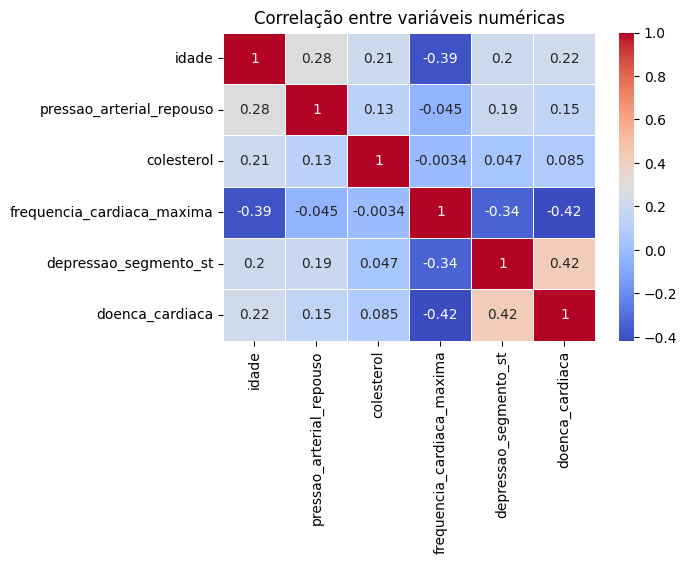

In [12]:
# vamo fazer um heatmap pra checar a correlação entre as variáveis
# aqi as variáveis categóricas são numéricas, mas elas não têm uma relação linear contínua
# no caso de tipo_dor_peito, por exemplo, o número 4 não é duas vezes mais que 2, então o resultado seria enganoso
# nesse cenário, vamo selecionar apenas as variáveis numéricas

colunas_numericas = ['idade', 'pressao_arterial_repouso', 'colesterol',
                     'frequencia_cardiaca_maxima', 'depressao_segmento_st',
                     'doenca_cardiaca']

correlacao = df[colunas_numericas].corr()
plt.figure(figsize = (6, 4))
sns.heatmap(correlacao, annot = True, cmap = 'coolwarm', linewidths = 0.5)
plt.title('Correlação entre variáveis numéricas')
plt.show()

- as variáveis que apresentam maior correlação com o target (doenca_cardiaca) são frequencia_cardiaca_maxima (-0.42) e depressao_segmento_st (0.42). isso confirma o que a gente já tinha identificado nos boxplots: quanto maior a frequencia_cardiaca_maxima, menor a chance de doença e quanto maior a depressão ST, maior a chance de doença;
- é curioso que colesterol e pressao_arterial_repouso sejam fatores de risco conhecidos para a doença, mas têm correlações baixas com o target isoladamente. isso sugere que o potencial preditivo dessas variáveis vai depender da interação com outras variáveis, o que vai ser capturado melhor no modelo do que na correlação simples;
- tbm dá pra ver que nenhum par de variáveis independentes (ao target) supera 0.39 de correlação, então não há indícios de multicolinearidade problemática (cálculo de VIF desnecessário).

## 3. Pré-processamento

antes de entrar no treinamento de qqr modelo, a gente precisa preparar os dados pra que o algoritmo consiga processar tudo corretamente. pra isso, vamo seguir dois passos principais:
- normalizar as variáveis numéricas pra mesma escala pra evitar que variáveis com magnitudes maiores dominem o modelo em relação a variáveis menores, independente da relevância real de cada uma (ex: colesterol variando entre 100 e 600, enquanto idade varia entre 20 e 80);
- converter as variáveis categóricas em colunas binárias, já que algoritmos de machine learning não trabalham com strings ou categorias nominais diretamente.

pra garantir que essas transformações sejam aplicadas sem data leakage,
vamo usar um Pipeline do scikit-learn pra que os aprendizados dos parâmetros aconteçam apenas nos dados de treino.

In [13]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# vamo começar separando as variáveis numéricas e categóricas
colunas_numericas = ['idade', 'pressao_arterial_repouso', 'colesterol', 'frequencia_cardiaca_maxima', 'depressao_segmento_st']
colunas_categoricas = ['sexo', 'tipo_dor_peito', 'glicemia_jejum_alta', 'ecg_repouso', 'angina_por_exercicio', 'inclinacao_st', 'numero_vasos_coloridos', 'resultado_talio']

# antes de definir o Pipeline, vamo separar X e Y
X = df.drop(columns=['doenca_cardiaca'])
Y = df['doenca_cardiaca']


como o dataset só tem 303 amostras, um split aleatório pode acabar concentrando mais de uma classe no teste, então vamo usar o split estratificado (stratify=Y) pra preservar a proporção 54/46 entre as classes em treino e teste

In [14]:
# vamo fazer o split estratificado
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# e, por ultimo, definir o preprocessor
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), colunas_numericas), ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), colunas_categoricas)])


na hora de definir o preprocessor, vamo usar drop = 'first' pra não codificar a primeira categoria explicitamente (sem perder nenhuma informação, já que a categoria ausente pode ser deduzida) e evitar a redundância que ocorreria se todas as categorias fossem codificadas explicitamente. isso vai ser importante aqi, já que manter as colunas redundantes pode fazer com que o modelo comece a tratar informação duplicada como se fossem dois sinais independentes, o que pode acabar distorcendo os coeficientes.


o handle_unknown='ignore' foi adicionado aqi no OneHotEncoder para lidar com categorias que podem não aparecer em todos os folds do cross-validation que vamo fazer mais pra frente, já que essa é uma situação esperada em datasets pequenos com categorias raras.

## 4. Modelagem

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

AUC-ROC - Regressão Logística: 0.9621


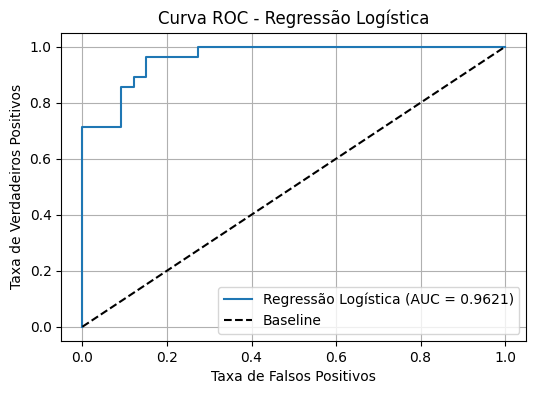

In [15]:
# o preprocessor já foi criado no pré-processamento, agora vamo criar o Pipeline completo com o modelo

from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline (steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42, max_iter=1000))])
pipeline_lr.fit(X_treino, Y_treino)

y_pred_pipeline_lr = pipeline_lr.predict(X_teste)
print(classification_report(Y_teste, y_pred_pipeline_lr))

probabilidades_pipeline_lr = pipeline_lr.predict_proba(X_teste)[:, 1]
auc_pipeline_lr = roc_auc_score(Y_teste, probabilidades_pipeline_lr)
fpr_pipeline_lr, tpr_pipeline_lr, _ = roc_curve(Y_teste, probabilidades_pipeline_lr)
print(f"AUC-ROC - Regressão Logística: {auc_pipeline_lr:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(fpr_pipeline_lr, tpr_pipeline_lr, label=f'Regressão Logística (AUC = {auc_pipeline_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Regressão Logística')
plt.legend()
plt.grid(True)
plt.show()


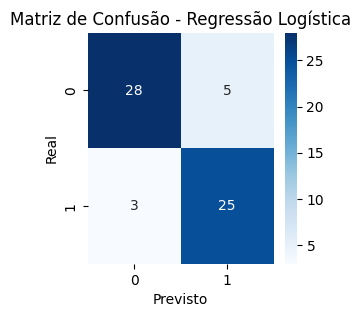

In [16]:
# vamo completar a análise com a matriz de confusão

matriz_pipeline_lr = confusion_matrix(Y_teste, y_pred_pipeline_lr)

plt.figure(figsize=(3, 3))
sns.heatmap(matriz_pipeline_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

nosso dataset é pequeno e tem só 61 amostras no conjunto de teste. com poucos pontos, cada threshold gera um salto visível em vez de uma linha suave. por isso a curva ROC apresenta um formato de degraus.

o modelo apresenta AUC-ROC de 0.9621, indicando um excelente poder descriminatório -> ele consegue distinguir corretamente pacientes com e sem doença em 96% dos casos.

o classification report tbm mostra que precisão e recall tão bem equilibrados em ambas as classes, sem viés pra nenhuma das duas (e isso é muito válido nesse caso, já que ambos os tipos de erros têm consequências relevantes no contexto clínico)

como nossa amostragm no teste não é muito grande, a avaliação do desempenho feito de forma pontual pode variar dependendo de quais pacientes caíram no teste. então, vamo incluir um cross-validation estratificado com 5 folds pra tentar estimar o desempenho de forma mais robusta, usando o conjunto de treino inteiro e calculando a média de 5 avaliações diferentes.

In [17]:
# vamo fazer o cross-validation estratificado pra buscar uma avaliação de desempenho mais robusta

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(pipeline_lr, X_treino, Y_treino,
                             cv=cv, scoring='roc_auc')

print(f"AUC-ROC médio - Regressão  Logística: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


AUC-ROC médio - Regressão  Logística: 0.9021 ± 0.0165


o cross validation com 5 folds mostrou o warning de categoria desconhecida como a gente já sabia que ia acontecer ao usar o handle_unknown='ignore'no preprocessor. o handle_unknown='ignore' tá funcionando como deve, mas ele tá avisando o que houve e o que ele tá fazendo.

em linhas gerais, ele garante que categorias que não aparecem em algum fold do cross-validation sejam codificadas como zeros em vez de causar erro. então, se alguma categoria aparece poucas vezes no dataset inteiro, é provável que em algum fold ela não apareça no treino, e aí, quando o modelo tenta transformar o fold de validação, encontra uma categoria que nunca viu. no caso do nosso dataset, o problema tá na categoria 2 do ecg_repouso, que é rara ao ponto de não aparecer em todos os folds de treino.

passando pra análise do resultado do cross-validando em si, a gente obteve AUC-ROC médio de 0.9021 (confirmando que o modelo generaliza bem) e um desvio padrão de 0.0165 (mostrando que o modelo é estável entre os folds), o que é muito bom e confirma que o o resultado no conjunto de teste não foi fruto de um split favorável.

a pequena diferença entre 0.9621 do teste e 0.9021 do cross-validation é normal já que em datasets pequenos, qualquer avaliação pontual (seja no teste ou num fold) pode variar para cima ou para baixo dependendo de quais amostras estão nela.

mas antes de definir esse como o modelo final, vamo incluir uma comparação com modelos de maior complexidade que podem capturar relações não-lineares entre as variáveis clínicas que a regressão logística não consegue.

              precision    recall  f1-score   support

           0       0.68      0.85      0.76        33
           1       0.75      0.54      0.62        28

    accuracy                           0.70        61
   macro avg       0.72      0.69      0.69        61
weighted avg       0.71      0.70      0.70        61

AUC-ROC - Árvore de Decisão: 0.7522


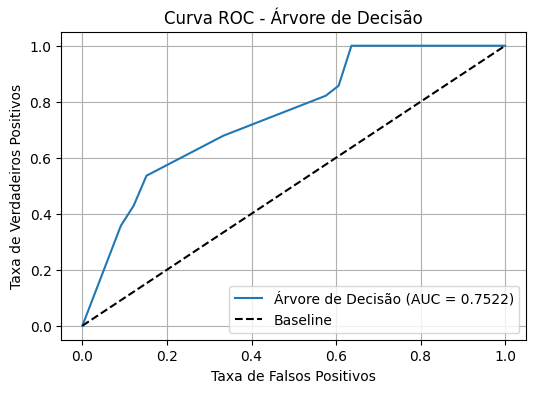

In [18]:
# vamo começar comparando com uma árvore de decisão

from sklearn.tree import DecisionTreeClassifier, plot_tree

pipeline_dt = Pipeline (steps=[('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(random_state=42, max_depth=4))])
# pra uma avaliação inicial o max_depth=4 já vai ser suficiente pra árvore não crescer muito e ficar ilegível
pipeline_dt.fit(X_treino, Y_treino)

y_pred_pipeline_dt = pipeline_dt.predict(X_teste)
print(classification_report(Y_teste, y_pred_pipeline_dt))

probabilidades_pipeline_dt = pipeline_dt.predict_proba(X_teste)[:, 1]
auc_pipeline_dt = roc_auc_score(Y_teste, probabilidades_pipeline_dt)
fpr_pipeline_dt, tpr_pipeline_dt, _ = roc_curve(Y_teste, probabilidades_pipeline_dt)
print(f"AUC-ROC - Árvore de Decisão: {auc_pipeline_dt:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(fpr_pipeline_dt, tpr_pipeline_dt, label=f'Árvore de Decisão (AUC = {auc_pipeline_dt:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Árvore de Decisão')
plt.legend()
plt.grid(True)
plt.show()

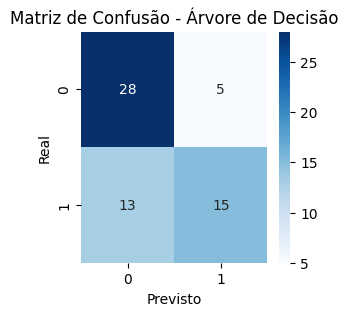

In [19]:
# e continuar a análise comparativa com a matriz de confusão

matriz_pipeline_dt = confusion_matrix(Y_teste, y_pred_pipeline_dt)

plt.figure(figsize=(3, 3))
sns.heatmap(matriz_pipeline_dt, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

a performance da árvore de decisão com AUC-ROC de 0.75 ficou bem abaixo da regressão logística (0.96).

além disso, a árvore apresenta um recall de apenas 0.54 pra classe 1. na matriz de confusão a gente consegue ver bem o impacto disso: 13 dos 28 pacientes com doença real foram classificados como saudáveis, enquanto que a regressão logística tinha identificado apenas 3 desses casos incorretamente. isso é muito crítico clinicamente e traz consequências graves, já que são pacientes que sairiam do exame sem diagnóstico.

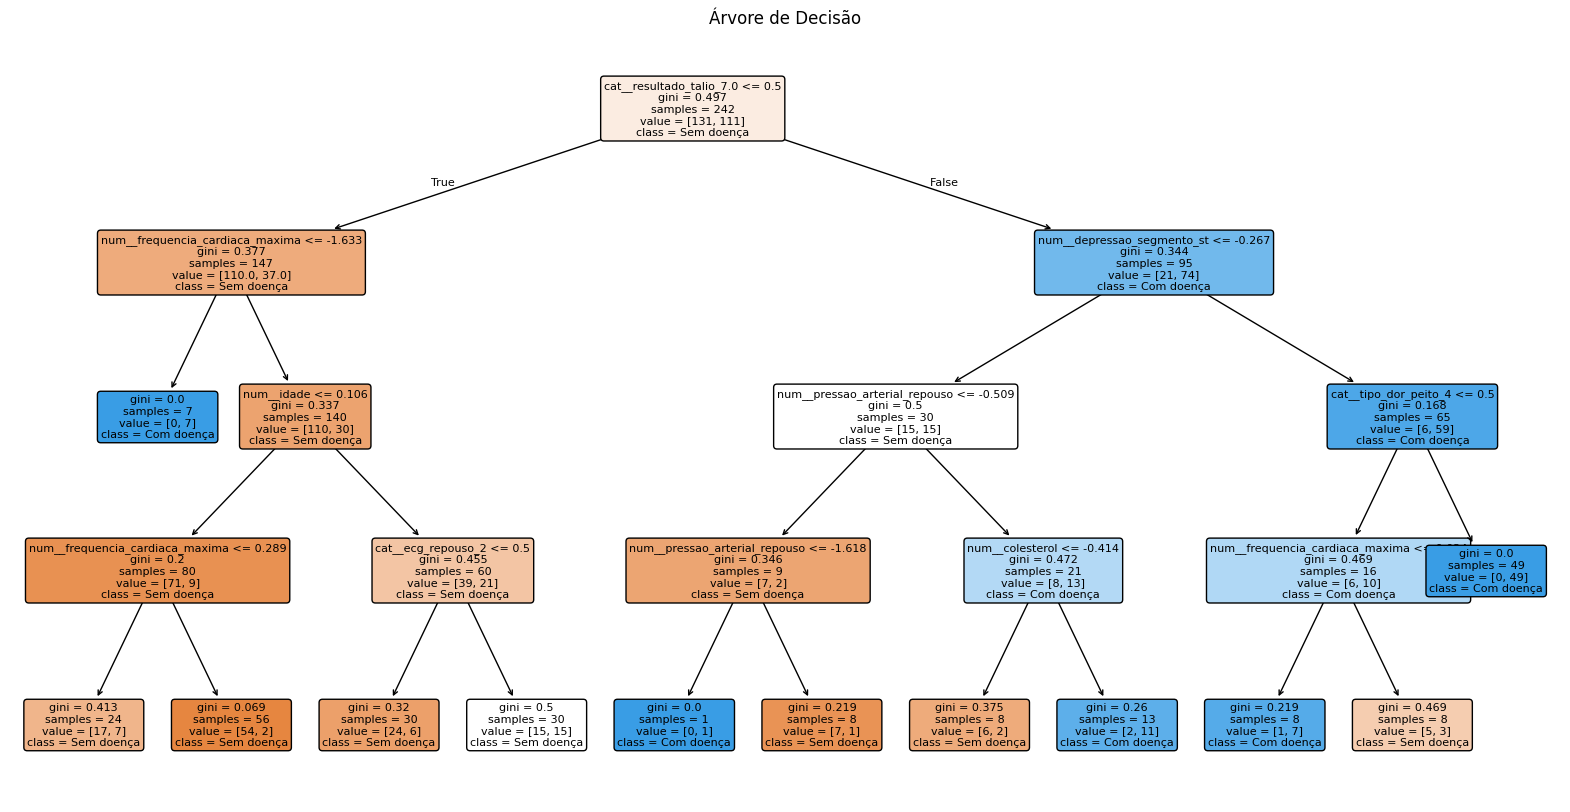

In [20]:
# vamo tbm incluir a visualização da árvore pra gente conseguir ver como o modelo toma decisões

plt.figure(figsize=(20, 10))
plot_tree(pipeline_dt.named_steps['classifier'],
          feature_names=pipeline_dt.named_steps['preprocessor'].get_feature_names_out(),
          class_names=['Sem doença', 'Com doença'],
          filled=True, rounded=True, fontsize=8)
plt.title('Árvore de Decisão')
plt.show()

na árvore, cada nó vai informar quantos pacientes chegaram nesse nó, quantos são "com doença" e "sem doença", a classificação majoritária desse nó e a impureza desse nó. essa impureza é chamada de "gini" e vai variar de 0 (nó puro, só uma classe) e 0.5 (máximo de mistura).

na raiz da árvore a gente tem a variável resultado_talio com categoria 7 considerando imediatamente pacientes dessa classe como "com doença". por aparecer no topo, a gente conclui que esse é o fator mais discriminatório globalmente.

logo abaixo, nos níveis seguintes, aparecem frequencia_cardiaca_maxima e depressao_segmento_st que, conforme a gente já tinha identificado no heatmap, tbm têm grande poder discriminatório e vão refinando a classificação. a partir daí, a ordem das variáveis não representa uma sequência linear de importância, já que cada galho da árvore é independente e resolve um subgrupo  diferente de pacientes. pra comparar a importância global de todas as variáveis, o correto é usar feature_importances no Random Forest (que vai ser o próximo modelo testado).

mesmo que as divisões principais sejam coerentes clinicamente, o problema da árvore astá nas folhas, já que os nós finais ainda têm muita mistura com gini alto. isso significa que o modelo chega ao final do processo de divisão sem conseguir separar bem as classes -> com apenas 242 amostras de treino e max_depth=4, a árvore não tem dados suficientes para refinar as decisões nos níveis mais profundos sem overfitting, resultando em um modelo que acerta bem os casos óbvios mas erra muito nos casos limítrofes.

In [21]:
# vamo incluir a cross-validation desse modelo tbm, pra seguir com a avaliação de desempenho

scores_dt = cross_val_score(pipeline_dt, X_treino, Y_treino, cv=cv, scoring='roc_auc')
print(f"AUC-ROC médio - Árvore de Decisão: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}")

AUC-ROC médio - Árvore de Decisão: 0.7827 ± 0.0505


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


como resultado do cross-validation estratificado pra árvore de decisão, a gente obteve AUC-ROC médio de 0.7827 (confirmando que o modelo de regressão logística performou muito melhor do que esse) e um desvio padrão de 0.0505 (que por ser maior do que o da regressão  logística, sugere menor estabilidade);

interessante notar que aqui o cross-validation (0.7827) ficou ligeiramente acima do AUC no conjunto de teste (0.7522) —> o oposto do que aconteceu na regressão logística. isso pode indicar que o conjunto de teste foi ligeiramente desfavorável para a árvore, ou que o modelo performa de forma um pouco inconsistente dependendo dos dados.

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

AUC-ROC - Random Forest: 0.9443


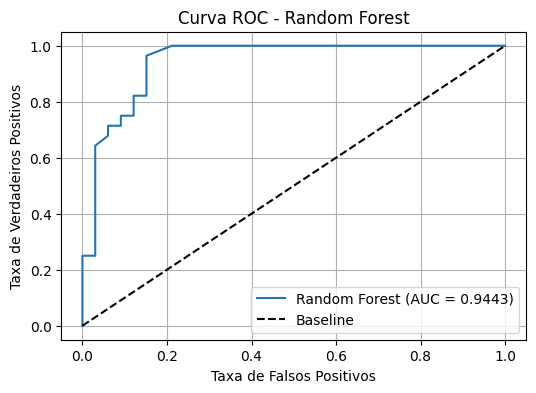

In [22]:
# vamo seguir pro modelo do Random Forest

from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline (steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))])
pipeline_rf.fit(X_treino, Y_treino)

y_pred_pipeline_rf = pipeline_rf.predict(X_teste)
print(classification_report(Y_teste, y_pred_pipeline_rf))

probabilidades_pipeline_rf = pipeline_rf.predict_proba(X_teste)[:, 1]
auc_pipeline_rf = roc_auc_score(Y_teste, probabilidades_pipeline_rf)
fpr_pipeline_rf, tpr_pipeline_rf, _ = roc_curve(Y_teste, probabilidades_pipeline_rf)
print(f"AUC-ROC - Random Forest: {auc_pipeline_rf:.4f}")

# curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr_pipeline_rf, tpr_pipeline_rf, label=f'Random Forest (AUC = {auc_pipeline_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

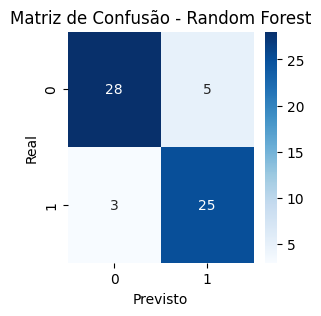

In [23]:
# vamo plotar a matriz de confusão tbm pra esse modelo

matriz_pipeline_rf = confusion_matrix(Y_teste, y_pred_pipeline_rf)
plt.figure(figsize=(3, 3))
sns.heatmap(matriz_pipeline_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

o random forest (AUC 0.9443) performou melhor que a árvore de decisão (0.7522) mas abaixo da regressão logística (0.9621).

random forest e regressão logística apresentaram classification report e matriz de confusão idênticos. isso acontece porque ambos dependem das previsões binárias geradas pelo predict() com threshold padrão de 0.5. se os dois modelos tomam as mesmas decisões binárias com esse threshold, as matrizes realmente vão ser idênticas.

em contrapartida, o AUC-ROC foi diferente nos dois modelos (mesmo que muito próximos com random forest 0.9443 e a regressão logística 0.9621), pq ele  é calculado com as probabilidades contínuas geradas pelo predict_proba(), capturando a qualidade dessas probabilidades em todos os thresholds possíveis, não só no 0.5.

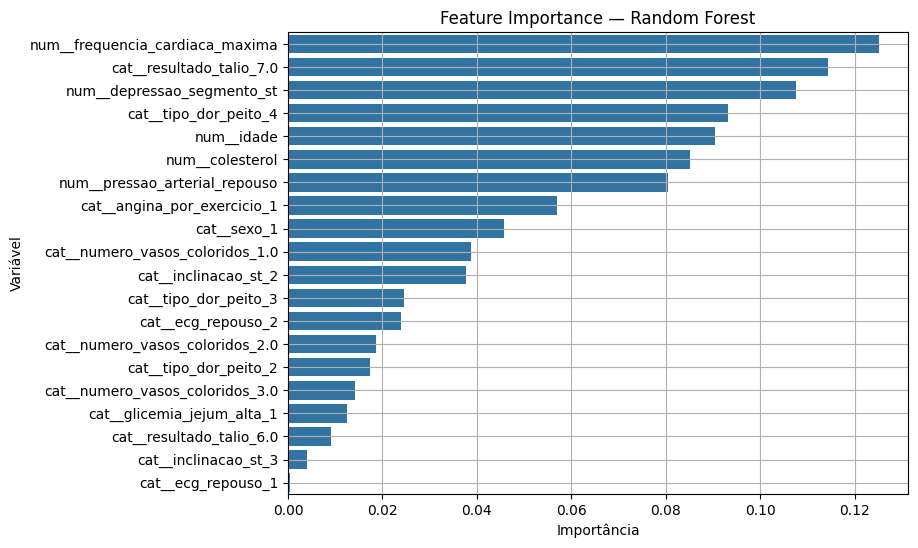

In [24]:
# vamo fzr um feature importance pra gente conseguir comparar a relevância global de todas as variáveis

importancias_rf = pipeline_rf.named_steps['classifier'].feature_importances_
feature_names_rf = pipeline_rf.named_steps['preprocessor'].get_feature_names_out()

importancias_rf_df = pd.DataFrame({'Variável': feature_names_rf,'Importância': importancias_rf}).sort_values('Importância', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importancias_rf_df, x='Importância', y='Variável')
plt.title('Feature Importance — Random Forest')
plt.grid(True)
plt.show()

esse resultado diverge um pouco do que a gente obteve na árvore de decisão. o top3 das mais discriminatórias tá igual, mas na árvore resultado_talio_7 aparecia na raiz como maior poder discriminatório. aqui no random forest, a frequencia_cardiaca_maxima lidera, seguida do resultado_talio_7 e tbm da depressao_segmento_st.

como o random forest agrega 100 árvores com subconjuntos aleatórios de features,  essa estimativa tende a ser mais robusta que a da árvore isolada, mas vamo confirmar se há overfitting na análise comparativa mais adiante.

mesmo tendo correlação linear baixa com o target no heatmap, colesterol e pressao_arterial_repouso aparecem aqui com importância moderada, então dá pra concluir que o random forest capturou contribuições não-lineares que a correlação de Pearson não detectou.

glicemia_jejum_alta e ecg_repouso_1 aparecem com importância muito baixa — consistente com o que os barplots já tinham sugerido na EDA.

In [25]:
# cross-validation
scores_rf = cross_val_score(pipeline_rf, X_treino, Y_treino, cv=cv, scoring='roc_auc')
print(f"AUC-ROC médio - Random Forest: {scores_rf.mean():.4f} ± {scores_rf.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


AUC-ROC médio - Random Forest: 0.8709 ± 0.0319


o cross-validation confirmou o padrão observado no conjunto de teste: AUC-ROC médio de 0.8709 e desvio padrão de 0.0319. isso mostra uma progressão coerente entre os modelos

em relação à performance:
- Regressão Logística: 0.9021 — maior performance
- Random Forest: 0.8709 — performance intermediária
- Árvore de Decisão: 0.7827 — menor performance

e em relação à estabilidade:
- Regressão Logística: 0.0165 — mais estável
- Random Forest: 0.0319 — estabilidade intermediária
- Árvore de Decisão: 0.0505 — menos estável

isso faz sentido, já que o ensemble de 100 árvores do Random Forest reduz a variância em relação a uma árvore isolada, mas ainda parece não atingir a estabilidade da regressão logística nesse dataset específico.

o ideal é que a gente inclua um outro modelo que confirme se as relações entre as variáveis clínicas e o target são predominantemente lineares, favorecendo modelos mais simples, ou se modelos de maior complexidade conseguem capturar padrões adicionais. Esse vai ser o teste definitivo de se a complexidade adicional traz ganho real nesse dataset ou não.

então, vamo testar agora o XGBoost que, diferente do Random Forest que treina árvores em paralelo de forma independente, treina árvores em sequência, com cada uma corrigindo os erros da anterior.

              precision    recall  f1-score   support

           0       0.88      0.85      0.86        33
           1       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

AUC-ROC - XGBoost: 0.9069


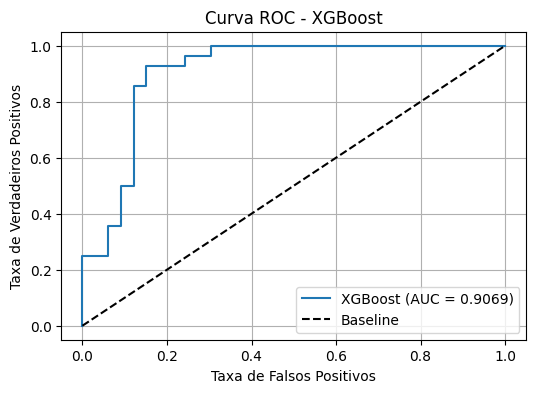

In [26]:
# vamo criar o modelo XGBoost

from xgboost import XGBClassifier

pipeline_xgb = Pipeline (steps=[('preprocessor', preprocessor), ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))])
pipeline_xgb.fit(X_treino, Y_treino)

y_pred_pipeline_xgb = pipeline_xgb.predict(X_teste)
print(classification_report(Y_teste, y_pred_pipeline_xgb))

probabilidades_pipeline_xgb = pipeline_xgb.predict_proba(X_teste)[:, 1]
auc_pipeline_xgb = roc_auc_score(Y_teste, probabilidades_pipeline_xgb)
fpr_pipeline_xgb, tpr_pipeline_xgb, _ = roc_curve(Y_teste, probabilidades_pipeline_xgb)
print(f"AUC-ROC - XGBoost: {auc_pipeline_xgb:.4f}")

# curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr_pipeline_xgb, tpr_pipeline_xgb, label=f'XGBoost (AUC = {auc_pipeline_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

o XGBoost obteve AUC-ROC de 0.9069, sendo o segundo pior resultado entre os quatro modelos (ganhando apenas pra árvore de decisão). é possível que o problema seja que esse modelo é complexo demais para o tamanho e a natureza desse dataset, já que, com apenas 303 amostras, o boosting sequencial pode acabar aprendendo ruído em vez de padrões reais, o que sugere overfitting.  então vamo aproveitar pra incluir uma confirmação de overfitting pra todos os modelos ao finalizar as análises do XGBoost.

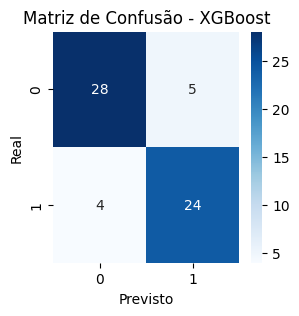

In [27]:
# vamo plotar a matriz de confusão tbm pra esse modelo

matriz_pipeline_xgb = confusion_matrix(Y_teste, y_pred_pipeline_xgb)
plt.figure(figsize=(3, 3))
sns.heatmap(matriz_pipeline_xgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost')
plt.show()

aqui na matriz de confusão, o XGBoost classificou 4 falsos negativos, enquanto a regressão logística e o random forest classificaram 3. a diferença é bem pequena, mas clinicamente isso é muito relevante.

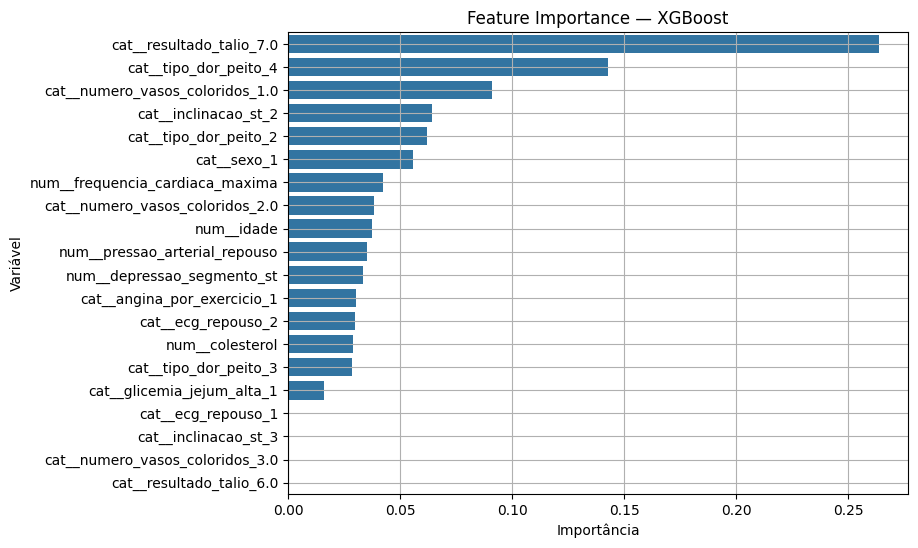

In [28]:
# vamo fzr um feature importance aqi tbm pra comparar com o resultado obtido no Random Forest

importancias_xgb = pipeline_xgb.named_steps['classifier'].feature_importances_
feature_names_xgb = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()

importancias_xgb_df = pd.DataFrame({'Variável': feature_names_xgb,'Importância': importancias_xgb}).sort_values('Importância', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importancias_xgb_df, x='Importância', y='Variável')
plt.title('Feature Importance — XGBoost')
plt.grid(True)
plt.show()

o feature importance divergiu bastante do Random Forest. além da ordem de importância em si estar bem diferente, aqui, resultado_talio_7 domina com algo próximo de 27% de importância e tipo_dor_peito_4 em segundo lugar com algo próximo de 14%, sugerindo uma distribuição muito mais desequilibrada do que no Random Forest.

essa análise do XGBoost mostra uma possível dependência excessiva de uma única variável. como o XGBoost é iterativo, ele pode estar aprendendo ruído, então o resultado do Random Forest é mais confiável como estimativa da importância real das variáveis.

In [29]:
# vamo incluir o cross-validation pra confirmar esse padrão

scores_xgb = cross_val_score(pipeline_xgb, X_treino, Y_treino, cv=cv, scoring='roc_auc')
print(f"AUC-ROC médio - XGBoost: {scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


AUC-ROC médio - XGBoost: 0.8507 ± 0.0318


vamo reavaliar a progressão de todos os modelos

em relação à performance:
- Regressão Logística: 0.9021 — maior performance
- Random Forest: 0.8709 — performance intermediária
- XGBoost: 0.8507
- Árvore de Decisão: 0.7827 — menor performance

e em relação à estabilidade:
- Regressão Logística: 0.0165 — mais estável
- XGBoost: 0.0318 — estabilidade intermediária (equivalente ao Random Forest)
- Random Forest: 0.0319 — estabilidade intermediária
- Árvore de Decisão: 0.0505 — menos estável

vamo fazer uma curva ROC comparativa pra consolidar visualmente essa progressão

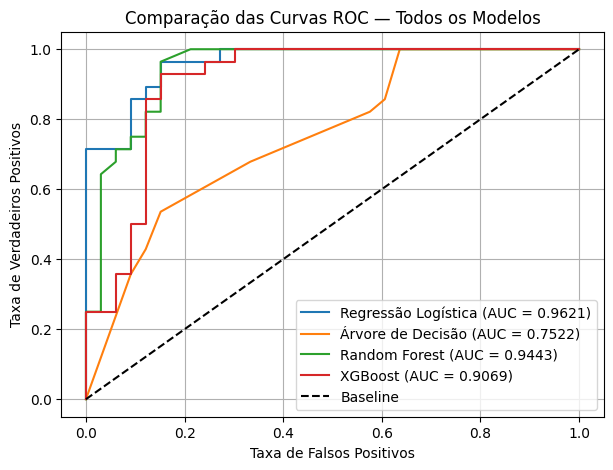

In [30]:
# vamo plotar a curva ROC comparativa dos 4 modelos pra fechar a etapa de modelagem

plt.figure(figsize=(7, 5))
plt.plot(fpr_pipeline_lr, tpr_pipeline_lr, label=f'Regressão Logística (AUC = {auc_pipeline_lr:.4f})')
plt.plot(fpr_pipeline_dt, tpr_pipeline_dt, label=f'Árvore de Decisão (AUC = {auc_pipeline_dt:.4f})')
plt.plot(fpr_pipeline_rf, tpr_pipeline_rf, label=f'Random Forest (AUC = {auc_pipeline_rf:.4f})')
plt.plot(fpr_pipeline_xgb, tpr_pipeline_xgb, label=f'XGBoost (AUC = {auc_pipeline_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Comparação das Curvas ROC — Todos os Modelos')
plt.legend()
plt.grid(True)
plt.show()

com a comparação dos quatro modelos, surgiu a hipótese de que modelos mais complexos podem estar aprendendo ruído em vez de padrões reais (sendo uma evidência direta de overfitting), principalmente o XGBoost, que concentrou importância desproporcional em uma única feature. pra verificar essa hipótese, vamo comparar o AUC-ROC de treino e teste de cada modelo pra avaliar se o modelo consegue performar bem nos dados que viu mas não generaliza para dados novos.

In [31]:
# vamo incluir uma tabela comparativa pra confirmar overfitting nos modelos

modelos = {
    'Regressão Logística': (pipeline_lr, probabilidades_pipeline_lr),
    'Árvore de Decisão': (pipeline_dt, probabilidades_pipeline_dt),
    'Random Forest': (pipeline_rf, probabilidades_pipeline_rf),
    'XGBoost': (pipeline_xgb, probabilidades_pipeline_xgb)
}

print(f"{'Modelo':<25} {'AUC Treino':>12} {'AUC Teste':>12} {'Diferença':>12}")
print("-" * 63)

for nome, (pipeline, probs_teste) in modelos.items():
    probs_treino = pipeline.predict_proba(X_treino)[:, 1]
    auc_treino = roc_auc_score(Y_treino, probs_treino)
    auc_teste = roc_auc_score(Y_teste, probs_teste)
    diferenca = auc_treino - auc_teste
    print(f"{nome:<25} {auc_treino:>12.4f} {auc_teste:>12.4f} {diferenca:>12.4f}")

Modelo                      AUC Treino    AUC Teste    Diferença
---------------------------------------------------------------
Regressão Logística             0.9279       0.9621      -0.0342
Árvore de Decisão               0.9188       0.7522       0.1667
Random Forest                   1.0000       0.9443       0.0557
XGBoost                         1.0000       0.9069       0.0931


no modelo de regressão logística, o AUC no teste (0.9621) foi maior que no treino (0.9279) e isso é o oposto de overfitting. com 61 amostras no teste, é completamente possível que o conjunto de teste tenha sido ligeiramente mais "fácil" para esse modelo do que o treino;

na árvore de decisão a gente tem uma diferença de 0.1667, confirmando um overfitting moderado;

o random forest e o xgboost apresentaram um AUC no treino de 1.0, que é o sinal mais claro possível de overfitting, significando que eles classificaram todos os pacientes do treino corretamente, memorizando o dataset inteiro, e depois caindo o desempenho no teste. o xgboost overfittou mais do que o random forest, o que faz todo sentido já que o boosting sequencial é mais agressivo em ajustar os dados de treino.

esses resultados, combinados com a performance superior da regressão logística, sugerem que:
- as relações entre as features e o target são predominantemente lineares nesse dataset;
- 303 amostras são insuficientes para que modelos complexos consigam explorar padrões não-lineares de forma confiável e generalizem sem overfitting.

provavelmente os dois fatores contribuem simultaneamente.

a regressão logística, de acordo com todas as análises que a gente fez até aqui, é o modelo com maior poder discriminatório, menor overfitting e maior estabilidade entre os folds, então esse é o modelo escolhido para otimização via GridSearch.

como ambos os modelos onde fizemos o feature importance overfittaram, essa análise serve como análise exploratória e não como uma conclusão definitiva. em ambos, temos como consenso que resultado_talio_7 e tipo_dor_peito_4 são relevantes, ao mesmo tempo que glicemia_jejum_alta e ecg_repouso_1 são irrelevantes. isso é consistente com o que a EDA já tinha sugerido, o que dá alguma confiança nas observações.

de toda forma, como o melhor modelo é a regressão logística, a interpretação de importância das variáveis mais confiável vai vir dos coeficientes da regressão logística otimizada. então vamo seguir pro GridSearch.

In [32]:
# vamo rodar o GridSearch pra otimizar os hiperparâmetros

from sklearn.model_selection import GridSearchCV

param_grid_lr = {'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}
# vamo usar liblinear pq ele suporta tanto l1 quanto l2


grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_treino, Y_treino)

print(f"Melhores parâmetros: {grid_lr.best_params_}")
print(f"Melhor AUC-ROC (cross-validation): {grid_lr.best_score_:.4f}")

Melhores parâmetros: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Melhor AUC-ROC (cross-validation): 0.9026


In [33]:
# agora vamo avaliar os melhores parâmetros no conjunto de teste

y_pred_grid_lr = grid_lr.predict(X_teste)
probabilidades_grid_lr = grid_lr.predict_proba(X_teste)[:, 1]
auc_grid_lr = roc_auc_score(Y_teste, probabilidades_grid_lr)

print(classification_report(Y_teste, y_pred_grid_lr))
print(f"AUC-ROC - Regressão Logística Otimizada: {auc_grid_lr:.4f}")

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

AUC-ROC - Regressão Logística Otimizada: 0.9632


o AUC-ROC no teste subiu de 0.9621 para 0.9632 e no cross-validation de 0.9021 para 0.9026 — melhora praticamente irrelevante estatisticamente mas tecnicamente positiva, que confirma que o modelo base já estava próximo do seu potencial máximo para esse dataset.

além disso, o GridSearch retornou C=10, penalty='l2' e solver='liblinear' como parâmetros ótimos. o penalty='l2' indica que reduzir todos os coeficientes proporcionalmente funciona melhor do que zerar os irrelevantes; e o C=10 sugere que o modelo precisa de mais flexibilidade do que o padrão (C=1) oferece.

## 5. Avaliação do Modelo Final

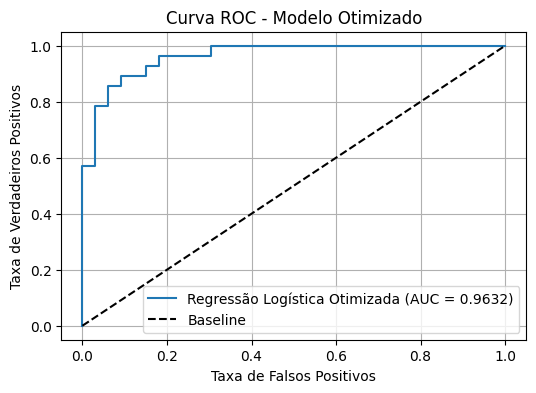

In [34]:
# vamo plotar a curva ROC do modelo otimizado

fpr_grid_lr, tpr_grid_lr, _ = roc_curve(Y_teste, probabilidades_grid_lr)

plt.figure(figsize=(6, 4))
plt.plot(fpr_grid_lr, tpr_grid_lr, label=f'Regressão Logística Otimizada (AUC = {auc_grid_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Modelo Otimizado')
plt.legend()
plt.grid(True)
plt.show()

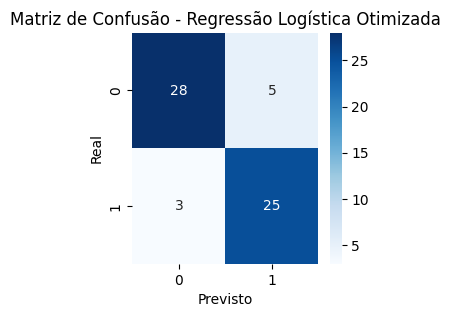

In [35]:
# e tbm a matriz de confusão pra avaliar se houve alguma diferença real pro modelo base

matriz_grid_lr = confusion_matrix(Y_teste, y_pred_grid_lr)
plt.figure(figsize=(3, 3))
sns.heatmap(matriz_grid_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística Otimizada')
plt.show()

comparando a curva ROC do modelo otimizado com a curva do modelo base, dá pra ver que a otimizada sobe mais rapidamente no início. com thresholds altos, ele consegue capturar mais verdadeiros positivos com menos falsos positivos. isso explica o AUC ligeiramente maior. essa suavidade na região inicial da curva sugere que as probabilidades do modelo otimizado estão melhores calibradas.

a matriz de confusão permaneceu idêntica pq, com threshold padrão de 0.5, ambos os modelos tomam as mesmas decisões binárias. a melhora do modelo otimizado está na qualidade das probabilidades e não nas classificações finais.

pra que a otimização seja refletida na matriz de confusão, o ideal é que a gente faça uma análise de limiar ajustando esse threshold de decisão pra entender como precisão, recall e F1 se comportam ao longo do espectro desses limiares

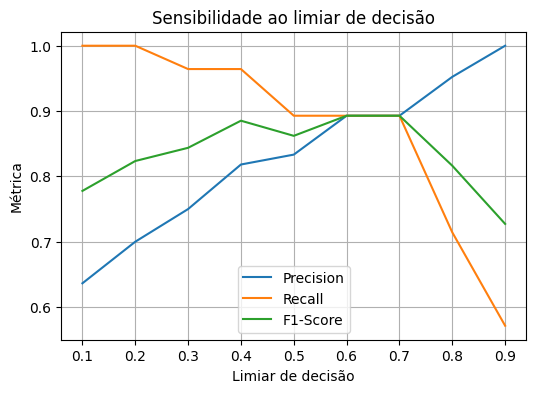

In [36]:
# vamo fazer a análise de sensibilidade ao limiar de decisão

from sklearn.metrics import precision_recall_fscore_support

limiares = np.arange(0.1, 1, 0.1)
precisions = []
recalls = []
f1_scores = []

for limiar in limiares:
    y_pred_lim = (probabilidades_grid_lr >= limiar).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        Y_teste, y_pred_lim, average='binary', zero_division=0)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

plt.figure(figsize=(6, 4))
plt.plot(limiares, precisions, label='Precision')
plt.plot(limiares, recalls, label='Recall')
plt.plot(limiares, f1_scores, label='F1-Score')
plt.xlabel('Limiar de decisão')
plt.ylabel('Métrica')
plt.title('Sensibilidade ao limiar de decisão')
plt.legend()
plt.grid(True)
plt.show()

o F1 é, basicamente, a média harmônica entre precisão e recall. então, o pico de F1 já representa o ponto de equilíbrio entre os dois. dá pra visualizar que o F1 atinge esse pico entre 0.6 e 0.7.

sendo assim, temos:
- com o limiar até 0.6 -> recall super alto e precisão baixa. o modelo captura quase todos os pacientes doentes, mas gera muitos alarmes falsos. isso serve pra um perfil ultra-conservador/conservador;
- limiar entre 0.6 e 0.7 -> é o melhor equilíbrio entre as métricas. isso serve pra um perfil moderado;
- limiar acima de 0.7 -> a precisão sobe, mas o recall cai drasticamente. o modelo só classifica como doente se ele tiver muita certeza, deixando passar muitos pacientes doentes reais. isso serve pra um modelo muito permissivo, sendo inadequado pra uma triagem clínica, por exemplo.

em linhas gerais, no contexto clínico, falsos negativos (que são pacientes doentes classificados como saudáveis) têm consequências potencialmente graves, já que o paciente sai do exame sem diagnóstico e sem tratamento. falsos positivos (que são os alarmes falsos) levam a exames adicionais desnecessários, que têm custo e desconforto, mas não colocam vidas em risco da mesma forma.

dessa forma a gente consegue definir uma direção clara a ser seguida:
- um limiar mais conservador (abaixo de 0.5) pode ser mais adequado para triagem clínica inicial, priorizando recall mesmo sacrificando alguma precision;
- o limiar ótimo pelo F1 (até agora identificado entre 0.6 e 0.7. vamo refinar mais esse número jajá) representa o melhor equilíbrio matemático;
- mas a decisão final vai depender do contexto de uso: se é uma triagem inicial ou uma confirmação diagnóstica.



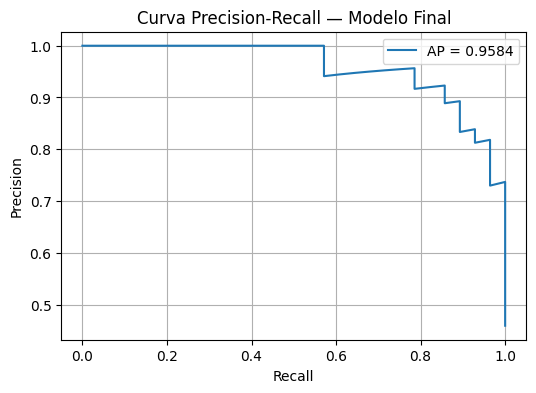

In [37]:
# vamo plotar a curva Precision-Recall pra seguir com a avaliação desse modelo otimizado

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(Y_teste, probabilidades_grid_lr)
ap = average_precision_score(Y_teste, probabilidades_grid_lr)

plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f'AP = {ap:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall — Modelo Final')
plt.legend()
plt.grid(True)
plt.show()

em uma distribuição balanceada (50/50), um classificador aleatório teria AP de 0.5. no caso da distribuição do nosso dataset, a nossa baseline gira em torno de 0.46. sendo assim, um AP de 0.9584 é excelente. além disso, a curva fica alta por quase todo o espectro de recall antes de cair, indicando um modelo forte.

In [38]:
# vamo identificar o limiar exato do pico de F1
# pra isso, vamo varrer de 0.5 a 0.78 com precisão de 0.01

from sklearn.metrics import f1_score

limiares_finos = np.arange(0.5, 0.8, 0.01)
f1_scores_finos = []

for limiar in limiares_finos:
    y_pred_lim = (probabilidades_grid_lr >= limiar).astype(int)
    f1 = f1_score(Y_teste, y_pred_lim, zero_division=0)
    f1_scores_finos.append(f1)

limiar_otimo = limiares_finos[np.argmax(f1_scores_finos)]
y_pred_limiar_otimo = (probabilidades_grid_lr >= limiar_otimo).astype(int)

print(f"Limiar ótimo: {limiar_otimo:.2f}")
print(f"F1 máximo: {max(f1_scores_finos):.4f}")

Limiar ótimo: 0.57
F1 máximo: 0.8929


pronto. o limiar ótimo ficou delimitado em 0.57. então, o modelo vai classificar como 'com doença' qualquer paciente com probabilidade maior ou igual a 57%, garantindo um F1 de 0.8929.
o F1 de 0.8929 com limiar 0.57 é melhor do que o 0.86 obtido com threshold padrão de 0.5, confirmando que o ajuste do limiar teve impacto real nas classificações (enquanto o GridSearch tinha melhorado só a qualidade das probabilidades).

em datasets desbalanceados, o limiar ótimo tende a se afastar do padrão de 0.5 pq o modelo precisa de mais ajuste pra lidar com a classe minoritária. no nosso caso, como nosso dataset é relativamente equilibrado (54/46), faz total sentido que esse limiar seja 0.57 e não se afaste tanto do padrão.

de toda forma, vamo refazer a matriz de confusão pra avaliar o impacto desse novo threshold na classificação.


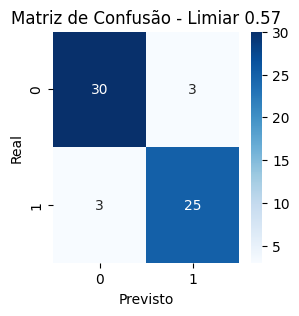

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        33
           1       0.89      0.89      0.89        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [39]:
# vamo refazer a matriz de confusão com o novo limiar pra avaliar a classificação

matriz_limiar_otimo = confusion_matrix(Y_teste, y_pred_limiar_otimo)

plt.figure(figsize=(3, 3))
sns.heatmap(matriz_limiar_otimo, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title(f'Matriz de Confusão - Limiar {limiar_otimo:.2f}')
plt.show()

print(classification_report(Y_teste, y_pred_limiar_otimo))

com o limiar de 0.57, o modelo manteve os mesmos 3 falsos negativos do threshold padrão mas reduziu os falsos positivos de 5 para 3 sem nenhum custo na detecção de pacientes doentes.

isso confirma que 0.57 é de fato o limiar ótimo para esse modelo, já que melhora a precision sem sacrificar o recall.

mas, pra triagem clínica inicial onde falsos negativos têm consequências graves, um limiar ainda mais conservador (abaixo de 0.5) pode ser considerado, priorizando capturar o máximo de pacientes doentes mesmo ao custo de mais alarmes falsos.

então, repito: no fim das contas, a decisão final vai depender do contexto de uso: se é uma triagem inicial ou uma confirmação diagnóstica.

In [40]:
# vamo testar uns thresholds menores só pra validar esse pensamento de mínimo de falsos negativos

for limiar_teste in [0.25, 0.3, 0.4, 0.45, 0.5, 0.57]:
    y_pred_teste = (probabilidades_grid_lr >= limiar_teste).astype(int)
    fn = confusion_matrix(Y_teste, y_pred_teste)[1, 0]
    fp = confusion_matrix(Y_teste, y_pred_teste)[0, 1]
    f1 = f1_score(Y_teste, y_pred_teste, zero_division=0)
    print(f"Limiar {limiar_teste:.2f} → FN: {fn} | FP: {fp} | F1: {f1:.4f}")

Limiar 0.25 → FN: 0 | FP: 10 | F1: 0.8485
Limiar 0.30 → FN: 1 | FP: 9 | F1: 0.8438
Limiar 0.40 → FN: 1 | FP: 6 | F1: 0.8852
Limiar 0.45 → FN: 2 | FP: 6 | F1: 0.8667
Limiar 0.50 → FN: 3 | FP: 5 | F1: 0.8621
Limiar 0.57 → FN: 3 | FP: 3 | F1: 0.8929


testando thresholds mais conservadores, a gente confirma que é possível reduzir os falsos negativos, chegando a 0 com limiar de 0.25. com isso, a gente pode discutir:
- limiar 0.57 (ótimo pelo F1): é o melhor equilíbrio matemático com 3 FN, 3 FP. adequado para confirmação diagnóstica onde precisão importa;
- limiar 0.30: captura quase todos os doentes mas gera muitos alarmes falsos (1 FN, 9 FP);
- limiar 0.25: nenhum paciente doente passa sem detecção, mas 10 pacientes saudáveis seriam encaminhados para exames desnecessários.

para triagem clínica inicial, onde o objetivo é não deixar nenhum paciente doente sem investigação, o limiar 0.25 ou 0.30 pode ser mais adequado, aceitando mais alarmes falsos em troca de maior segurança diagnóstica. mas aumentar esses números de falsos positivos tbm trazem um custo concreto, não só financeiro como de riscos associados à alguns exames feitos desnecessariamente.

pra entender quais variáveis estão por trás dessas classificações, e identificar perfis que merecem atenção adicional mesmo quando o score está abaixo do threshold, vamo analisar os coeficientes do modelo otimizado e os SHAP values




## 6. Interpretabilidade

                           Variável  Coeficiente  Odds Ratio
16  cat__numero_vasos_coloridos_2.0     2.441855   11.494341
17  cat__numero_vasos_coloridos_3.0     2.363381   10.626820
15  cat__numero_vasos_coloridos_1.0     2.008342    7.450956
8             cat__tipo_dor_peito_4     1.777096    5.912659
5                       cat__sexo_1     1.531523    4.625218
19         cat__resultado_talio_7.0     1.416145    4.121202
13             cat__inclinacao_st_2     1.180795    3.256961
6             cat__tipo_dor_peito_2     0.878926    2.408313
12      cat__angina_por_exercicio_1     0.505275    1.657442
3   num__frequencia_cardiaca_maxima    -0.405588    0.666585
1     num__pressao_arterial_repouso     0.388727    1.475102
10               cat__ecg_repouso_1    -0.381535    0.682813
11               cat__ecg_repouso_2     0.352797    1.423042
4        num__depressao_segmento_st     0.268819    1.308419
9        cat__glicemia_jejum_alta_1    -0.238878    0.787511
2                   num_

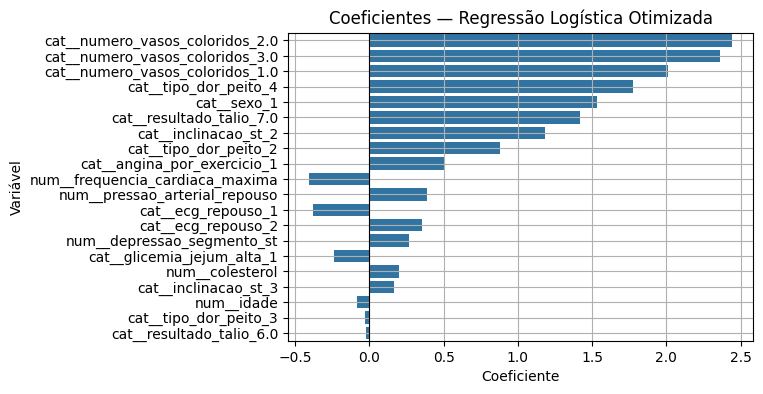

In [41]:
# vamo analisar os coeficientes do modelo pra entender o impacto de cada uma na variável alvo

coeficientes_grid_lr = grid_lr.best_estimator_.named_steps['classifier'].coef_[0]
variaveis_grid_lr = grid_lr.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

coeficientes_grid_lr_df = pd.DataFrame({
    'Variável': variaveis_grid_lr,
    'Coeficiente': coeficientes_grid_lr,
    'Odds Ratio': np.exp(coeficientes_grid_lr)
}).sort_values('Coeficiente', key=abs, ascending=False)

print(coeficientes_grid_lr_df)

plt.figure(figsize=(6, 4))
sns.barplot(data=coeficientes_grid_lr_df, x='Coeficiente', y='Variável')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regressão Logística Otimizada')
plt.grid(True)
plt.show()

como já tinha sido avaliado, essa análise/interpretação dos coeficientes do modelo otimizado é mais confiável do que o feature importance dos modelos que overfittaram.

a partir dessa análise dá pra perceber que:
- os três coeficientes mais altos pertencem a numero_vasos_coloridos (categorias 1.0, 2.0 e 3.0), todos positivos e com valores muito próximos entre si (2.44, 2.36 e 2.01), sugerindo que a presença de vasos comprometidos é mais determinante do que a quantidade exata;
- tipo_dor_peito_4 (assintomático) aparece com coeficiente alto e positivo, sendo consistente com a isquemia silenciosa que discutimos na EDA -> a ausência de sintomas não protege contra a doença;
- sexo_1 (masculino) aparece com coeficiente relevante — clinicamente documentado: homens têm maior prevalência de doença arterial coronariana, especialmente em faixas etárias mais jovens. os barplots tbm já haviam sugerido esse padrão;
- resultado_talio_7 (defeito reversível) também aparece com coeficiente positivo relevante, confirmando que uma isquemia ativa identificada no teste de estresse é um fator de risco real;
- frequencia_cardiaca_maxima aparece com coeficiente negativo, mostrando que quanto maior a frequência cardíaca máxima, menor o risco. tbm se mostrando consistente com tudo que identificamos desde os boxplots;
- curiosamente, idade aparece com coeficiente muito baixo (-0.087). isso não significa, necessariamente, que idade não importa clinicamente, mas que controlando todas as outras variáveis, seu efeito direto é pequeno. possivelmente porque o efeito da idade pode já estar sendo capturado indiretamente por outras variáveis como numero_vasos_coloridos e resultado_talio.

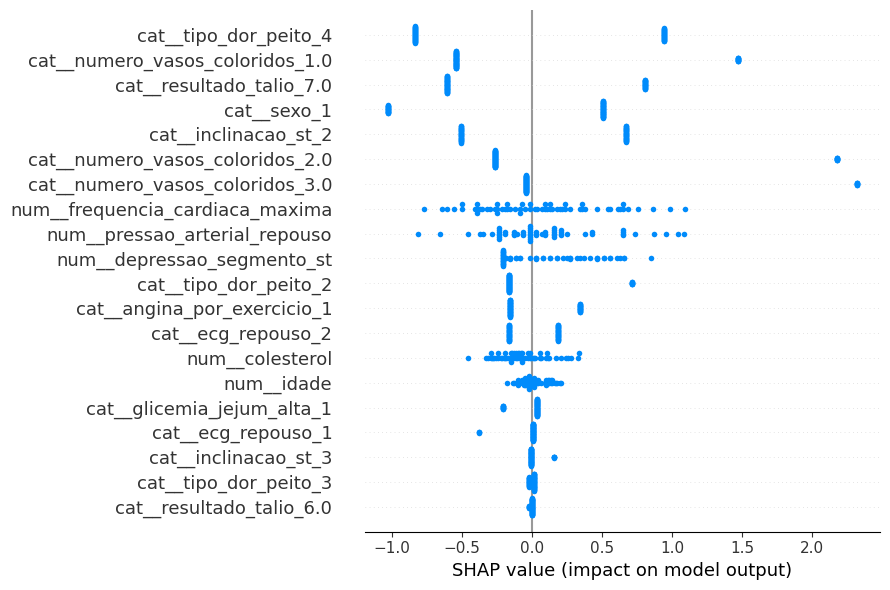

In [42]:
# vamo incluir os SHAP values pra decompor a previsão do modelo em contribuições individuais de cada feature pra cada paciente

import shap

explainer = shap.LinearExplainer(grid_lr.best_estimator_.named_steps['classifier'],grid_lr.best_estimator_.named_steps['preprocessor'].transform(X_treino))
shap_values = explainer.shap_values(grid_lr.best_estimator_.named_steps['preprocessor'].transform(X_teste))
shap.summary_plot(shap_values, feature_names=variaveis_grid_lr, plot_size=(9, 6))

os coeficientes medem o impacto por variável independente da frequência. o SHAP considera tanto o impacto quanto a frequência com que cada categoria aparece nos dados, então vamo usar o SHAP pra aprofundar a análise dos coeficientes, mostrando o impacto de cada variável pra cada paciente individualmente.

pelo resultado plotado, dá pra gente observar que:
- tipo_dor_peito_4 lidera no SHAP por ser uma categoria muito frequente no dataset, afetando muitos pacientes — mesmo tendo um coeficiente menor que numero_vasos_coloridos. numero_vasos_coloridos_2 e 3 têm coeficientes maiores, mas aparecem mais abaixo no SHAP por serem categorias menos frequentes;
- frequencia_cardiaca_maxima e pressao_arterial_repouso mostram muitos pontos espalhados ao longo do eixo, indicando que o impacto dessas variáveis é altamente dependente do valor específico de cada paciente. esse resultado mostra que não é uma relação binária como nas categóricas, mas sim uma influência contínua que varia caso a caso;
- resultado_talio_6 (defeito fixo) e resultado_talio_7 (defeito reversível) divergem em comportamento -> o defeito reversível tem impacto positivo relevante em alguns pacientes, enquanto o defeito fixo tem impacto próximo de zero. isso tbm é clinicamente coerente, já que o defeito fixo indica dano permanente que pode já ter sido tratado, enquanto o reversível indica isquemia ativa;
- glicemia_jejum_alta e ecg_repouso_1 continuam com impacto próximo de zero — confirmando o que os barplots já haviam sugerido: essas variáveis têm baixo poder preditivo nesse dataset.

apesar de algumas divergências na ordem de importância entre os coeficientes e o SHAP, o que já era esperado graças à diferença de metodologia entre os dois, há coerência nas variáveis que ambos identificam como relevantes e irrelevantes. associando isso ao que a EDA já tinha sugerido, conseguimos reforçar a confiabilidade das conclusões.

## 7. Conclusões Clínicas

algumas limitações importantes devem ser consideradas antes de qualquer aplicação clínica:
- o dataset ser pequeno, com apenas 303 pacientes, torna ele insuficiente pra uma validação clínica robusta. modelos médicos em produção são validados em milhares de pacientes;
- os dados são da Cleveland Clinic, de 1988, e o perfil demográfico e protocolos diagnósticos podem não refletir a população atual;
- o modelo não substitui diagnóstico médico. ele é apenas uma ferramenta de apoio à decisão. a decisão final deve sempre envolver avaliação clínica completa;
- o modelo foi treinado e testado na mesma distribuição de dados. desempenho em populações diferentes pode variar significativamente.

mas a partir dos resultados do modelo e das análises de interpretabilidade, a gente pode traçar algumas diretrizes práticas pra a aplicação clínica:

a escolha do limiar deve ser estratégica e vai depender do contexto de uso:
- pra triagem clínica inicial (população de risco, exame preventivo): limiar 0.25-0.30 minimiza falsos negativos (0-1), ao custo de mais alarmes falsos (9-10 falsos positivos). essa abordagem seria adequada quando o objetivo é não deixar nenhum caso passar sem investigação;
- já pro caso de confirmação diagnóstica, onde a precisão importa, o limiar 0.57 (que é o limiar ótimo pelo F1) oferece o melhor equilíbrio matemático (com 3 falsos negativos, 3 falsos positivos).

de forma geral, pacientes classificados como 'sem doença' mas com numero_vasos_coloridos > 0, tipo_dor_peito_4 = 1 ou resultado_talio_7 = 1 (ou seja: resultados preocupantes nas variáveis mais impactantes) devem ser reavaliados clinicamente pra uma investigação mais aprofundada, já que essas variáveis têm alto peso individual e sua presença isolada já é sinal de alerta mesmo quando o score geral está abaixo do threshold. seguindo a mesma linha, pacientes de baixo risco podem seguir acompanhamento preventivo de rotina.

no fim, toda decisão clínica precisa considerar o contexto do paciente, a infraestrutura disponível e o julgamento do profissional de saúde. o modelo seria apenas um instrumento de apoio dentro desse processo, não uma decisão autônoma.
